# 📊 Netflix Data Analysis

This project analyzes the Netflix dataset to understand content trends, distribution, and patterns using data visualization techniques.


In [ ]:
# 📁 Dataset Information

* (Netflix Titles Dataset)
* Features:

  * Title
  * Type (Movie / TV Show)
  * Country
  * Date Added
  * Release Year
  * Rating
  * Duration
  * Genre


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
sns.set_style("whitegrid")  

%matplotlib inline

df = pd.read_csv('netflix_titles.csv')

In [3]:
df['date_added'] = df['date_added'].astype(str).str.strip()

df['date_added'] = pd.to_datetime(df['date_added'],errors = 'coerce')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [4]:
#check missing values
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added        10
month_added       10
dtype: int64


In [5]:
# 🧹 Data Cleaning

#In this step, we handle missing values, convert data types, and prepare the dataset for analysis.



# Fill missing values
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['cast'] = df['cast'].fillna('Unknown')


# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Feature Engineering
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Extra Feature
df['is_recent'] = df['year_added'] >= 2018

# Genre extraction
df['genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])

# Handle director (many missing)
df['director'] = df['director'].fillna('Unknown')

# Remove duplicates
df.drop_duplicates(inplace=True)

# Clean text columns
df['country'] = df['country'].str.strip()

# Extract duration (numeric)
df['duration_num'] = df['duration'].str.extract(r'(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'], errors='coerce')

# Drop rows where date is missing
df = df.dropna(subset=['date_added'])
df = df.dropna(subset=['duration_num'])


df.head();

In [6]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
is_recent       0
genre           0
duration_num    0
dtype: int64


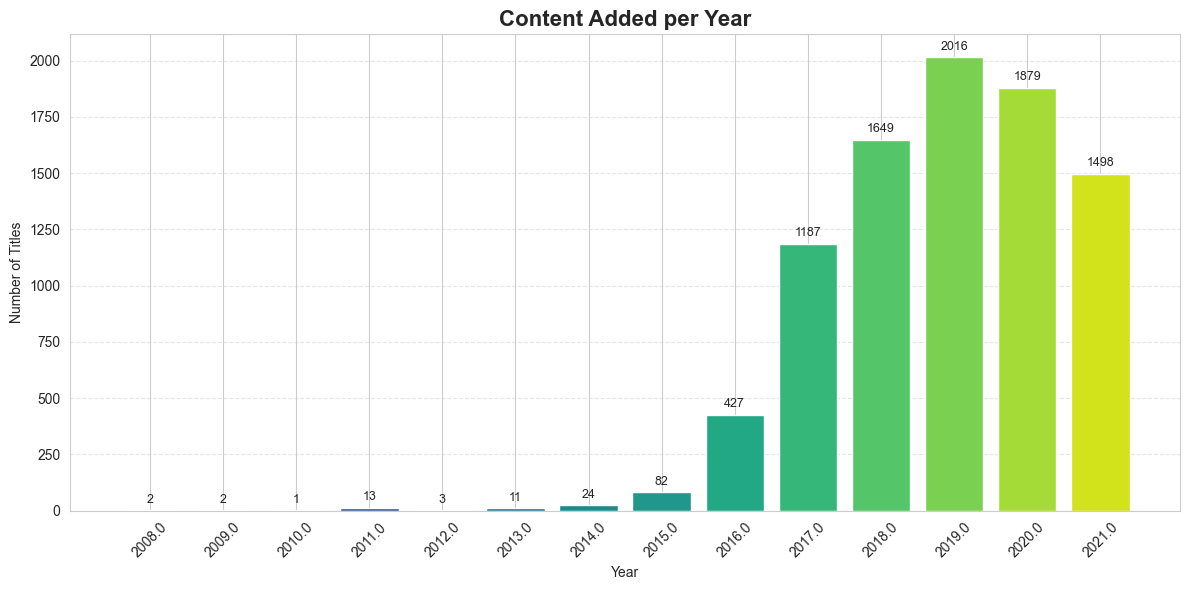

In [7]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))

colors = sns.color_palette("viridis", len(year_counts))

bars = plt.bar(year_counts.index.astype(str), year_counts.values, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, int(yval),
             ha='center', va='bottom', fontsize=9)

plt.title('Content Added per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


type
Movie      6128
TV Show    2666
Name: count, dtype: int64


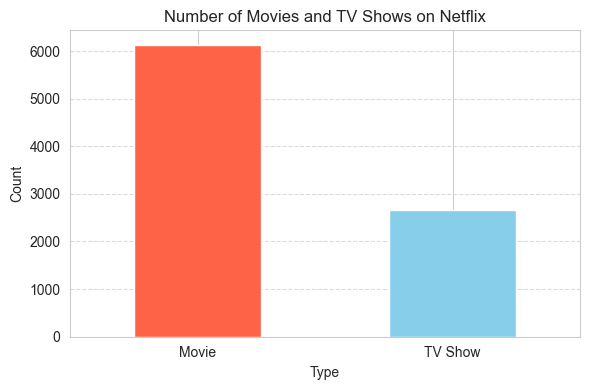

In [8]:
# Count of Movies vs TV Shows
content_count = df['type'].value_counts()
print(content_count)


plt.figure(figsize=(6,4))
content_count.plot(kind='bar', color=['tomato', 'skyblue'])
plt.title('Number of Movies and TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


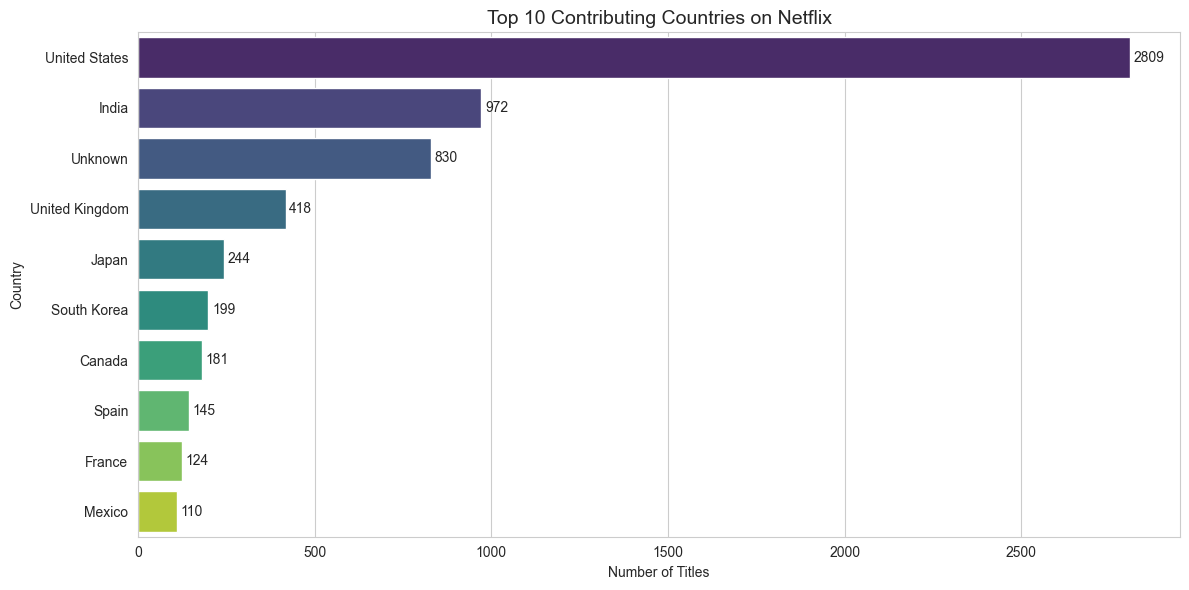

In [9]:
plt.figure(figsize=(12, 6))

top_countries = df['country'].value_counts().head(10)

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index, 
    palette='viridis',
    legend=False    
)

# Add values
for i, v in enumerate(top_countries.values):
    plt.text(v + 10, i, str(v), va='center')

plt.title('Top 10 Contributing Countries on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.tight_layout()
plt.show()




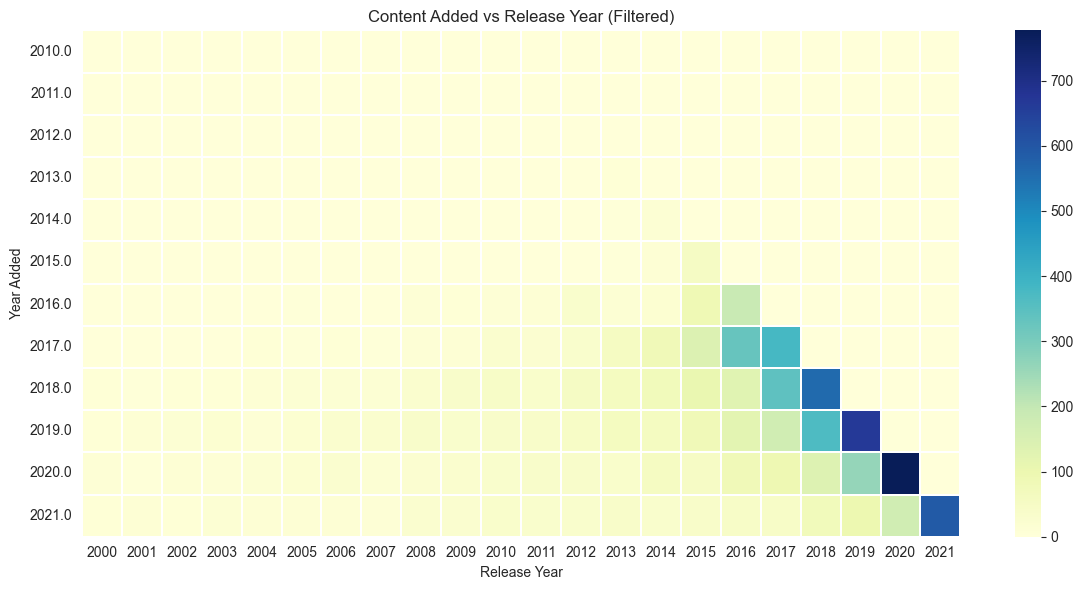

In [10]:
# Create clean dataframe
df_clean = df.copy()

# Ensure numeric
df_clean['year_added'] = pd.to_numeric(df_clean['year_added'], errors='coerce')
df_clean['release_year'] = pd.to_numeric(df_clean['release_year'], errors='coerce')

# Create pivot
heatmap_data = df_clean.pivot_table(
    index='year_added',
    columns='release_year',
    aggfunc='size',
    fill_value=0
)

# Filter safely
heatmap_data = heatmap_data[
    (heatmap_data.index >= 2010) & (heatmap_data.index <= 2021)
]

heatmap_data = heatmap_data.loc[:, 
    (heatmap_data.columns >= 2000) & (heatmap_data.columns <= 2021)
]

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.3)

plt.title('Content Added vs Release Year (Filtered)')
plt.xlabel('Release Year')
plt.ylabel('Year Added')

plt.tight_layout()
plt.show()

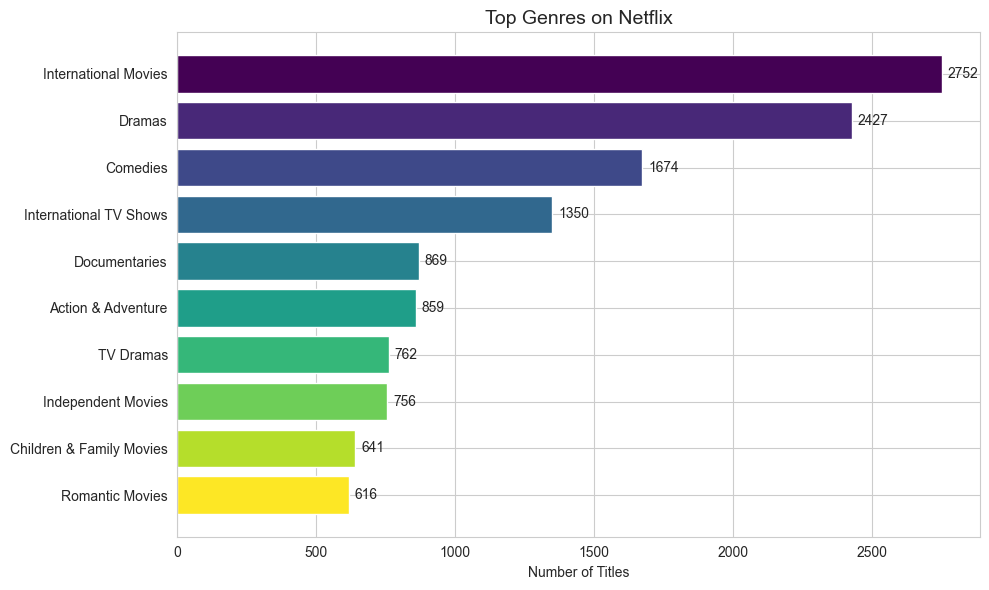

In [17]:
import numpy as np

plt.figure(figsize=(10, 6))

# Create gradient colors (same as your old style)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_genres)))

# Plot
bars = plt.barh(top_genres.index, top_genres.values, color=colors)

# Add values on bars
for i, v in enumerate(top_genres.values):
    plt.text(v + 20, i, str(v), va='center')

plt.xlabel("Number of Titles")
plt.title("Top Genres on Netflix", fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

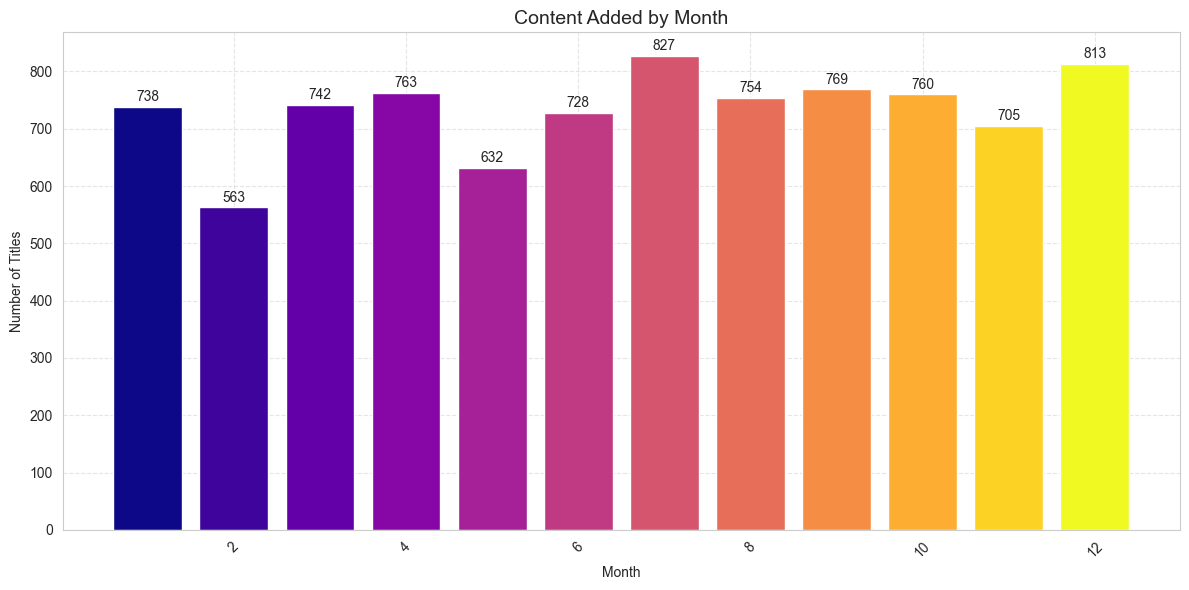

In [14]:
import numpy as np

# Define monthly trend FIRST
monthly_trend = df['month_added'].value_counts().sort_index()

plt.figure(figsize=(12, 6))

colors = plt.cm.plasma(np.linspace(0, 1, len(monthly_trend)))

bars = plt.bar(monthly_trend.index, monthly_trend.values, color=colors)

# Add values
for x, y in zip(monthly_trend.index, monthly_trend.values):
    plt.text(x, y + 10, str(y), ha='center')

plt.title('Content Added by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

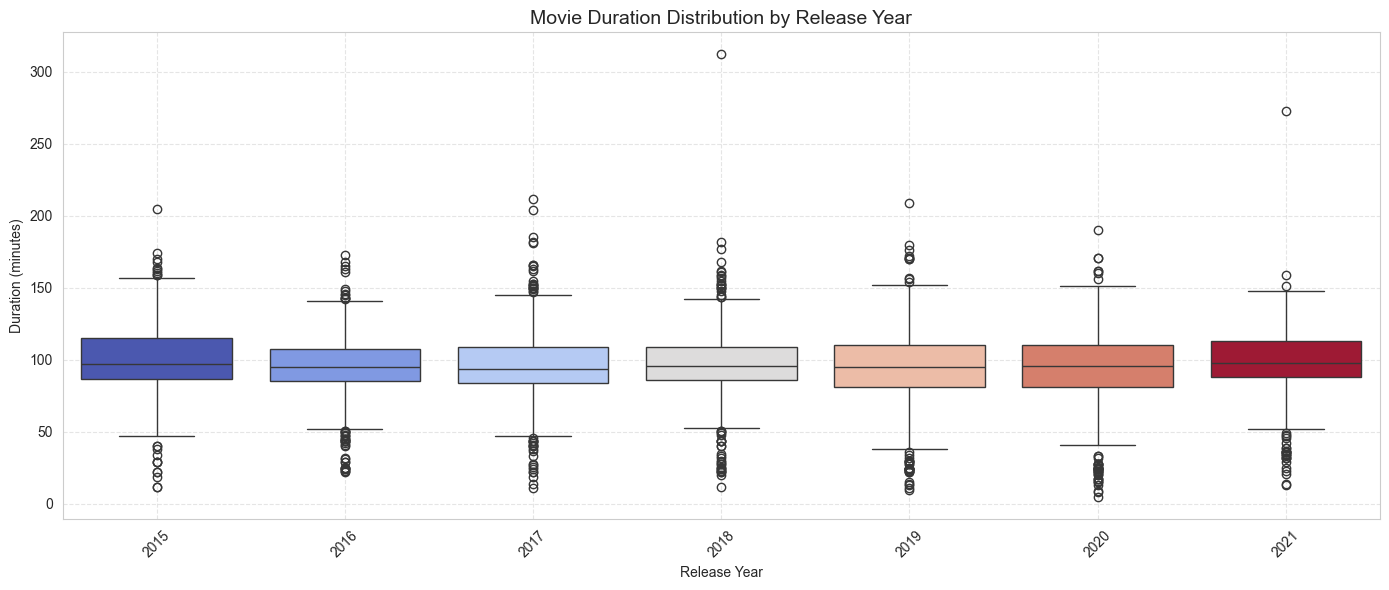

In [21]:
# Extract duration
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Filter only movies
df_movies = df[df['type'] == 'Movie']

# Filter recent years
recent = df_movies[df_movies['release_year'] >= 2015]

# Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=recent,
    x='release_year',
    y='duration_minutes',
    hue='release_year',
    palette='coolwarm',
    legend=False
)

plt.title('Movie Duration Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

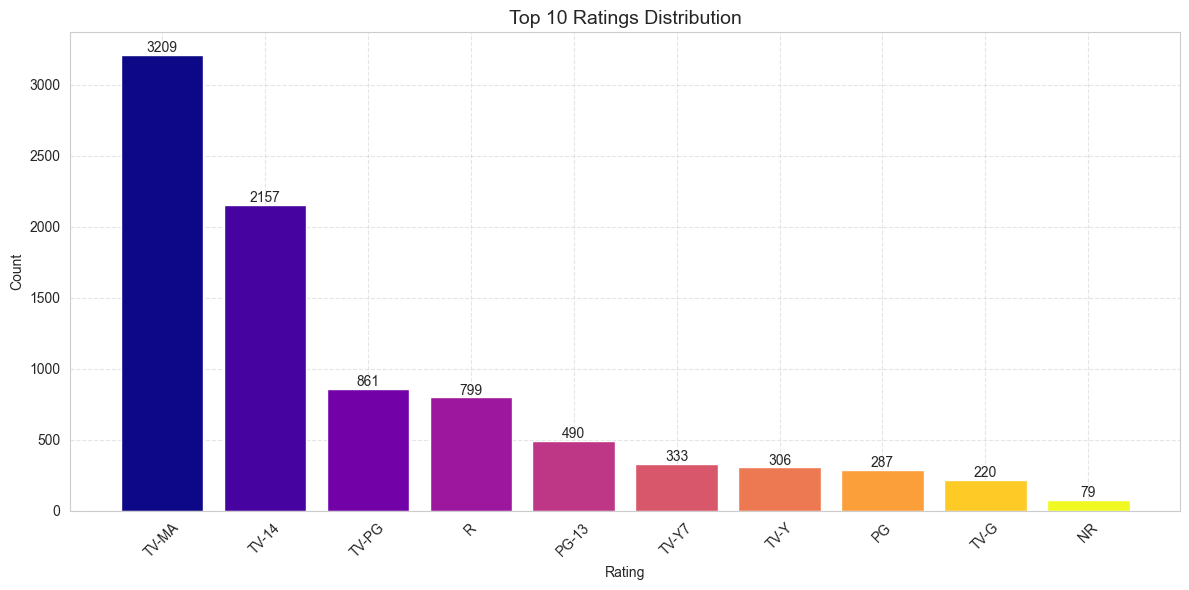

In [56]:
import numpy as np

plt.figure(figsize=(12, 6))

# Sort values
order = df['rating'].value_counts().index[:10]
counts = df['rating'].value_counts().loc[order]

# Create gradient colors
colors = plt.cm.plasma(np.linspace(0, 1, len(order)))

# Plot using matplotlib
bars = plt.bar(order, counts, color=colors)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        str(int(height)),
        ha='center'
    )

plt.title('Top 10 Ratings Distribution', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

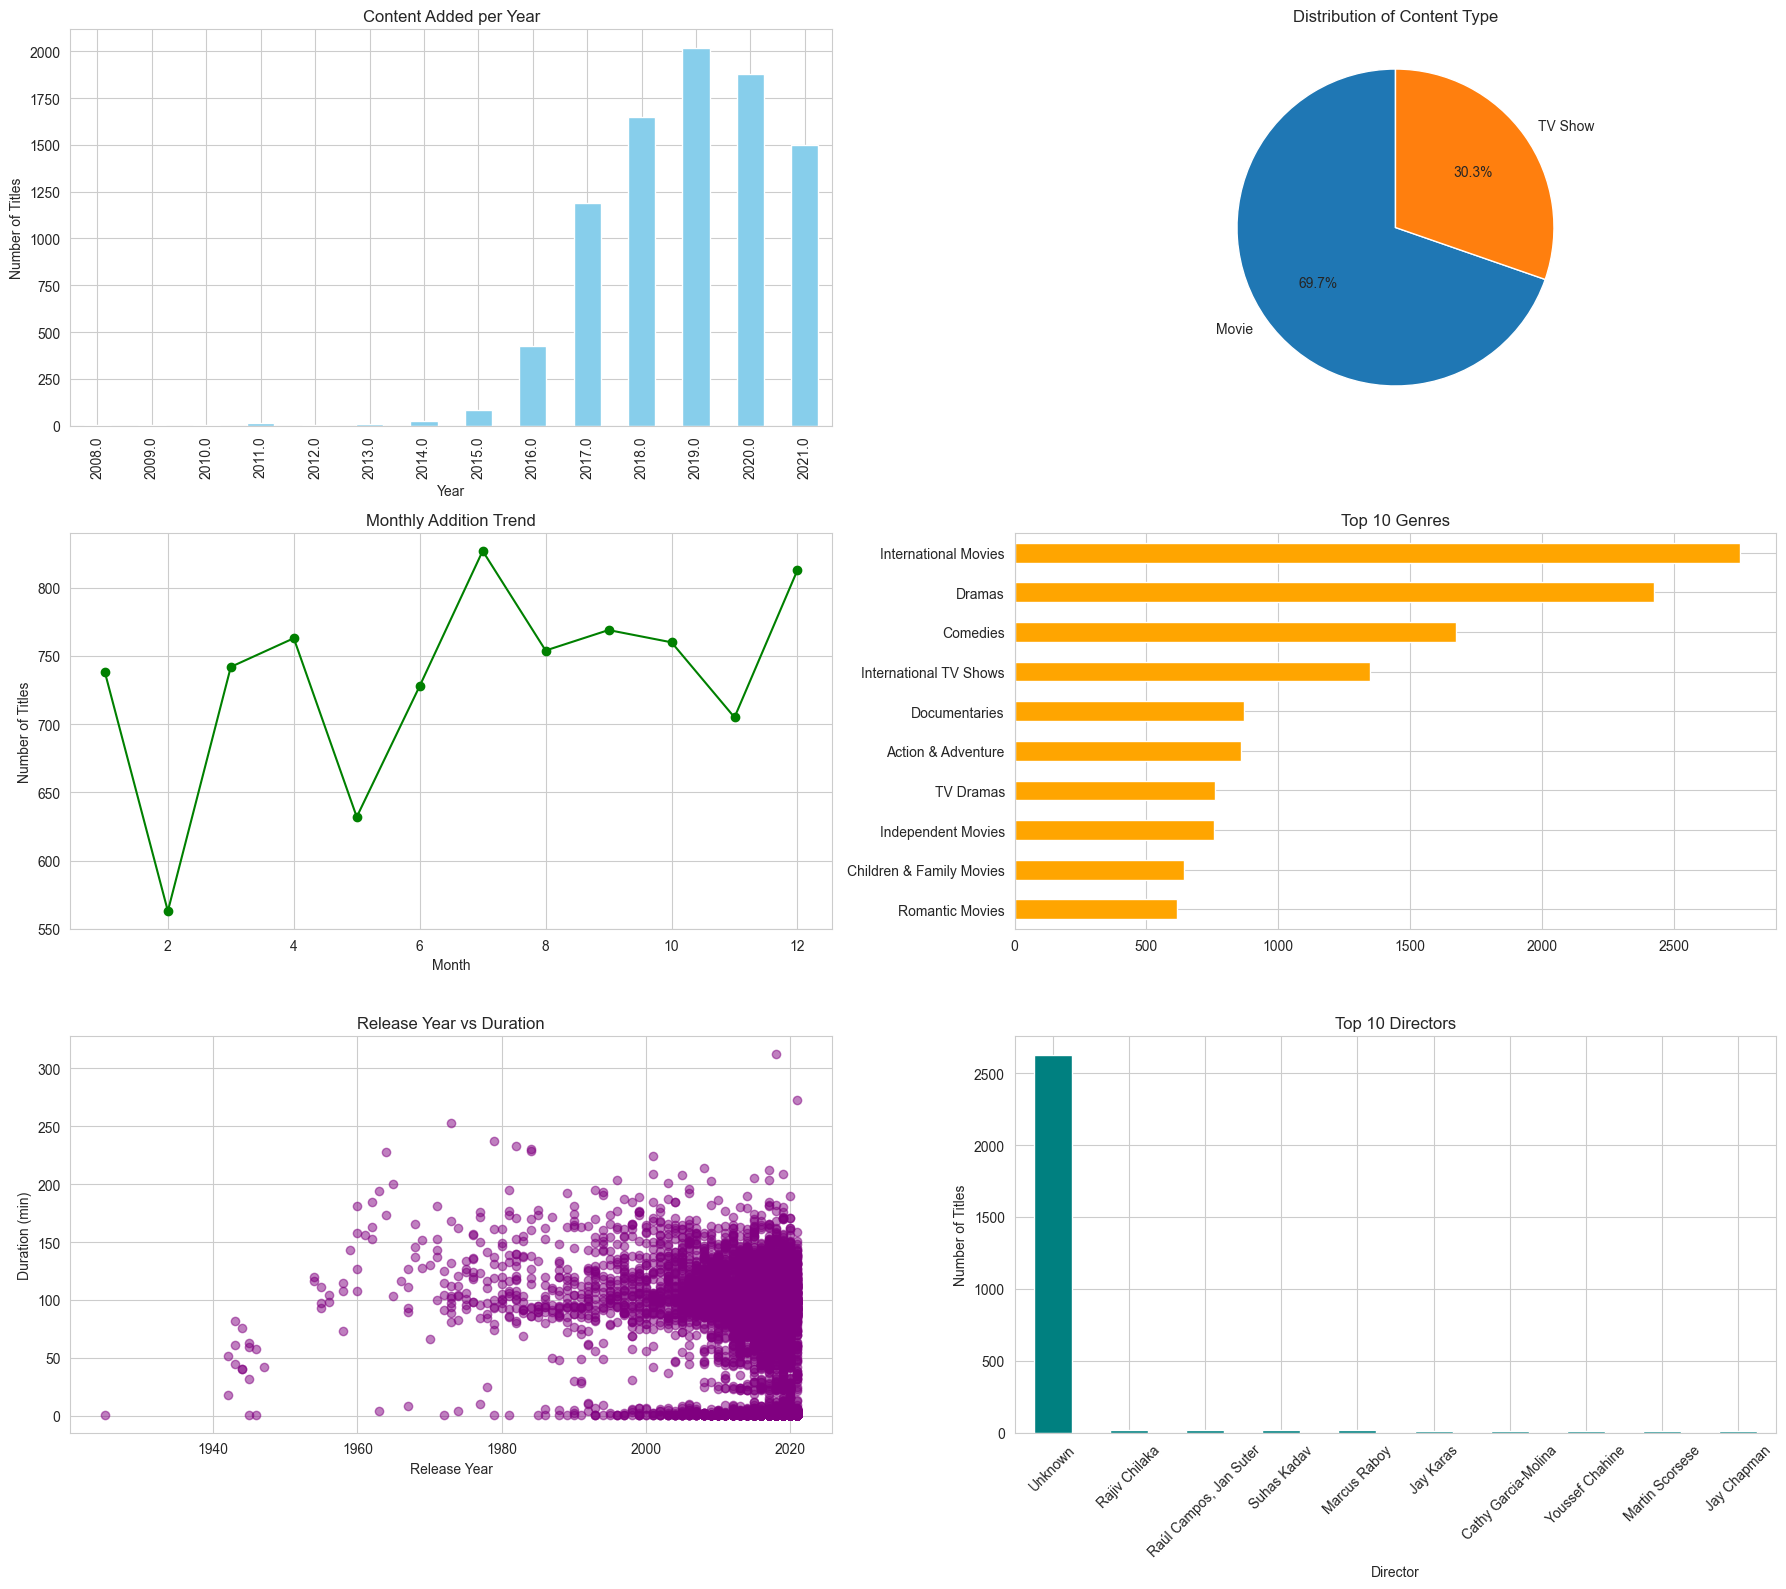

In [57]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)


fig, axs = plt.subplots(3, 2, figsize=(18, 16))  # 3 rows, 2 cols


df['year_added'].value_counts().sort_index().plot(kind='bar', ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title('Content Added per Year')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Number of Titles')


df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, ax=axs[0, 1])
axs[0, 1].set_ylabel('')
axs[0, 1].set_title('Distribution of Content Type')


monthly_trend = df['month_added'].value_counts().sort_index()
axs[1, 0].plot(monthly_trend.index, monthly_trend.values, marker='o', linestyle='-', color='green')
axs[1, 0].set_title('Monthly Addition Trend')
axs[1, 0].set_xlabel('Month')
axs[1, 0].set_ylabel('Number of Titles')


df['listed_in'] = df['listed_in'].fillna('Unknown')
genre_counts = df['listed_in'].str.split(', ', expand=True).stack().value_counts().head(10)
genre_counts.plot(kind='barh', ax=axs[1, 1], color='orange')
axs[1, 1].set_title('Top 10 Genres')
axs[1, 1].invert_yaxis()

df.dropna(subset=['release_year', 'duration_num'], inplace=True)
axs[2, 0].scatter(df['release_year'], df['duration_num'], alpha=0.5, color='purple')
axs[2, 0].set_title('Release Year vs Duration')
axs[2, 0].set_xlabel('Release Year')
axs[2, 0].set_ylabel('Duration (min)')


df['director'] = df['director'].fillna('Unknown')
top_directors = df['director'].value_counts().head(10)
top_directors.plot(kind='bar', ax=axs[2, 1], color='teal')
axs[2, 1].set_title('Top 10 Directors')
axs[2, 1].set_xlabel('Director')
axs[2, 1].set_ylabel('Number of Titles')
axs[2, 1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

In [58]:
#Data Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Select columns
df = df[['type', 'country', 'release_year', 'duration', 'listed_in']]
df = df.dropna()

# Convert duration
df['duration'] = df['duration'].str.extract(r'(\d+)').astype(int)\

# Encoding
df['type'] = LabelEncoder().fit_transform(df['type'])
df['country'] = LabelEncoder().fit_transform(df['country'])
df['listed_in'] = LabelEncoder().fit_transform(df['listed_in'])

# Split
X = df[['country', 'release_year', 'duration', 'listed_in']]
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.993103448275862


In [60]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9981191222570532


In [61]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9987460815047022


In [62]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9981191222570532


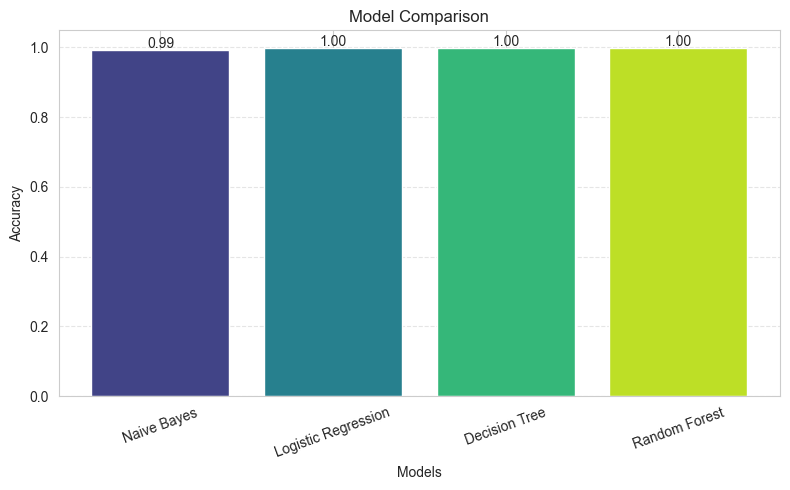

In [63]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [nb_acc, lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(8, 5))

# Create gradient (dark → light like your image)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(models)))

# Plot
bars = plt.bar(models, accuracies, color=colors)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.2f}',
        ha='center',
        fontsize=10
    )

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=20)

# Light grid like your style
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# 📊 Netflix Data Analysis Report

## 1. Introduction

This project focuses on analyzing the Netflix dataset to understand content trends, distribution, and patterns. 
    With the rapid growth of OTT platforms, Netflix has become one of the leading streaming services worldwide.
    This analysis aims to explore how content has evolved over time, which countries contribute the most,
    and what types of content are most popular.

---

## 2. Objective

* To perform data cleaning and preprocessing on the dataset
* To analyze trends in content addition over time
* To study the distribution of movies and TV shows
* To identify top contributing countries and popular genres
* To extract meaningful insights using data visualization

---

## 3. Dataset Description

The dataset used contains information about Netflix titles, including:

* Title
* Type (Movie / TV Show)
* Country
* Date Added
* Release Year
* Rating
* Duration
* Genre

---

## 4. Data Cleaning and Preprocessing

The following steps were performed to prepare the dataset:

* Handled missing values by filling categorical columns with appropriate values
* Converted the `date_added` column into datetime format
* Extracted new features such as `year_added` and `month_added`
* Removed duplicate records
* Cleaned text data (e.g., removing extra spaces)
* Extracted numerical values from the duration column

---

## 5. Feature Engineering

To enhance analysis, new features were created:

* **Year Added**: Extracted from date to analyze growth trends
* **Month Added**: Used for seasonal analysis
* **Genre**: Extracted from the listed categories
* **Is Recent**: Classified content added after 2018

These features helped in gaining deeper insights beyond the original dataset.

---

## 6. Data Visualization and Analysis

Various visualizations were created to analyze the dataset:

* **Content Growth Over Time**: Shows a rapid increase in content after 2016
* **Movies vs TV Shows**: Movies dominate the platform, but TV shows are growing
* **Top Countries**: The United States contributes the most content, followed by India
* **Top Genres**: Drama and International Movies are the most common
* **Monthly Trends**: Certain months show higher content additions
* **Heatmaps and Boxplots**: Used to analyze relationships and distributions

---

## 7. Key Insights

* Netflix experienced significant growth in content addition after 2016
* The United States is the largest contributor of content
* Movies form the majority of content, but TV shows are increasing steadily
* Drama and international content are the most popular genres
* Content addition shows seasonal patterns across months

---

## 8. Research Support

According to studies on OTT platforms, streaming services like Netflix have experienced exponential growth due
to increased internet accessibility and changing consumer behavior. The findings from this dataset support these
trends, especially the surge in content after 2016.

---

## 9. Conclusion

This project successfully analyzed Netflix data to uncover trends and patterns. The analysis highlights the rapid 
growth of streaming platforms and the dominance of certain countries and genres. Feature engineering and 
visualization techniques helped in extracting meaningful insights, making this study both informative and impactful.

---

## 10. Future Scope

* Integrating external datasets such as IMDb ratings for deeper analysis
* Performing sentiment analysis on content descriptions
* Building recommendation systems based on user preferences
* Expanding analysis to other streaming platforms

---
